# Customizing and exporting graphical models and CPTs as image (pdf, png)

| | | |
|-|-|-|
|[ ![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[ ![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) |[ ![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fwrappers%2Fpyagrum%2Fdoc%2Fsphinx%2Fnotebooks%2F98-Tools_customizingAndExportingBNs.ipynb)

In [1]:
from pylab import *
import matplotlib.pyplot as plt

In [2]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb

In [3]:
bn = gum.fastBN("a->b->c->d;b->e->d->f;g->c")
gnb.flow.row(bn, gnb.getInference(bn))

## customizing colours and width for model and inference

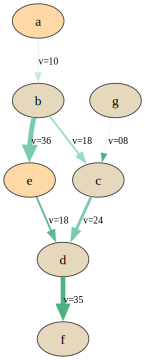

In [4]:
def nodevalue(n):
  return 0.5 if n in "aeiou" else 0.7


def arcvalue(a):
  return (10 - a[0]) * a[1]


def arcvalue2(a):
  return (a[0] + a[1] + 5) / 22


gnb.showBN(
  bn,
  nodeColor={n: nodevalue(n) for n in bn.names()},
  arcWidth={a: arcvalue(a) for a in bn.arcs()},
  arcLabel={a: f"v={arcvalue(a):02d}" for a in bn.arcs()},
  arcColor={a: arcvalue2(a) for a in bn.arcs()},
)

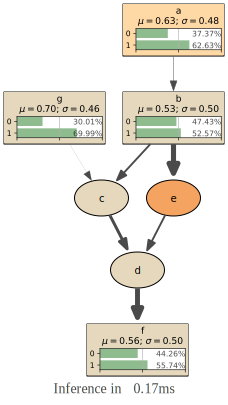

In [5]:
gnb.showInference(
  bn,
  targets={"a", "g", "f", "b"},
  evs={"e": 0},
  nodeColor={n: nodevalue(n) for n in bn.names()},
  arcWidth={a: arcvalue(a) for a in bn.arcs()},
)

In [6]:
gnb.flow.row(
  gnb.getBN(bn, nodeColor={n: nodevalue(n) for n in bn.names()}, arcWidth={a: arcvalue(a) for a in bn.arcs()}),
  gnb.getInference(bn, nodeColor={n: nodevalue(n) for n in bn.names()}, arcWidth={a: arcvalue(a) for a in bn.arcs()}),
)

In [7]:
mycmap = plt.get_cmap("Reds")
formyarcs = plt.get_cmap("winter")
gnb.flow.row(
  gnb.getBN(
    bn,
    nodeColor={n: nodevalue(n) for n in bn.names()},
    arcColor={a: arcvalue2(a) for a in bn.arcs()},
    cmapNode=mycmap,
    cmapArc=formyarcs,
  ),
  gnb.getInference(
    bn,
    nodeColor={n: nodevalue(n) for n in bn.names()},
    arcColor={a: arcvalue2(a) for a in bn.arcs()},
    arcWidth={a: arcvalue(a) for a in bn.arcs()},
    cmapNode=mycmap,
    cmapArc=formyarcs,
  ),
)

## Modifying graph's layout

Every graph or graphical models can be translated into a pyDot's representaton (a `pydot.Dot` object). In this graphical representation, it is possible to manipulate the positions of the node. pyAgrum proposes two functions `gum.utils.dot_layout` to help modifying this layout.

### Layout for Bayesian network

In [8]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.lib.utils as gutils
import pyagrum.lib.bn2graph as gumb2g

bn = gum.fastBN("A->B<-C<-D")
bn2 = gum.fastBN("A->B->C<-D")

graph = gumb2g.BN2dot(bn)

graph2 = gumb2g.BN2dot(bn2)
l = gutils.dot_layout(graph)
print(f"Layout proposed by dot for BN :{l}")
gutils.apply_dot_layout(graph2, l)

graph3 = gumb2g.BN2dot(bn2)
# l["C"],l["A"]=l["A"],l["C"]
l["D"], l["C"], l["B"], l["A"] = (
  gutils.DotPoint(0, 0),
  gutils.DotPoint(1, 1),
  gutils.DotPoint(2, 2),
  gutils.DotPoint(3, 3),
)
gutils.apply_dot_layout(graph3, l)
gnb.flow.row(bn, bn2, graph2, graph3, captions=["BN", "BN2", "BN2 with the same layoutas BN", "Layout changed by hand"])

Layout proposed by dot for BN :{'D': DotPoint(x=0.375, y=2.25), 'B': DotPoint(x=0.875, y=0.25), 'C': DotPoint(x=0.375, y=1.25), 'A': DotPoint(x=1.375, y=1.25)}


### Layout for other graphical models and for inference

In [9]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.lib.utils as gutils
import pyagrum.lib.id2graph as gum2gr

model = gum.fastID("*D->$L<-E<-H->L;E->D")
gnb.flow.add(model)
gum.config.push()
gum.config["influenceDiagram", "utility_shape"] = "diamond"

figure = gum2gr.ID2dot(model)
l = gutils.dot_layout(figure)

# changing LAYOUT
# making some horizontal space
for i, p in l.items():
  l[i] = gutils.DotPoint(1.5 * p.x, p.y)
# E at the vertical of L, at the horizontal of D
l["E"] = gutils.DotPoint(l["L"].x, l["D"].y)
# H symetric of D w.r.t (EL)
l["H"] = gutils.DotPoint(2 * l["E"].x - l["D"].x, l["D"].y)

gutils.apply_dot_layout(figure, l)
gnb.flow.add(figure)

gnb.flow.display()
gum.config.pop()

In [10]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.lib.utils as gutils
import pyagrum.lib.id2graph as gum2gr

model = gum.fastID("*D->$L<-E<-H->L;E->D")
gnb.flow.add(gnb.getInference(model))

figure = gum2gr.LIMIDinference2dot(model, evs={}, targets={}, size=None, engine=None)
l = gutils.dot_layout(figure)

# changing LAYOUT
# making some horizontal space
for i, p in l.items():
  l[i] = gutils.DotPoint(3 * p.x, p.y)
# E at the vertical of L, at the horizontal of D
l["E"] = gutils.DotPoint(l["L"].x, l["D"].y)
l["D"] = gutils.DotPoint(l["D"].x / 2, l["D"].y)
l["H"] = gutils.DotPoint(l["L"].x * 3 / 2, l["D"].y)

gutils.apply_dot_layout(figure, l)
gnb.flow.add(figure)

gnb.flow.display()

## Exporting model and inference as image

Exporting as image (pdf, png, etc.) has been gathered in 2 functions : `pyagrum.lib.image.export()` and `pyagrum.lib.image.exportInference()`. The argument are the same as for `pyagrum.notebook.show{Model}` and `pyagrum.notebook.show{Inference}`.

In [11]:
import os
import pyagrum.lib.image as gumimage
from IPython.display import Image  # to display the exported images

os.makedirs("out/export", exist_ok=True)

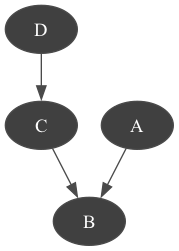

In [12]:
gumimage.export(bn, "out/export/test_export.png")

Image(filename="out/export/test_export.png")

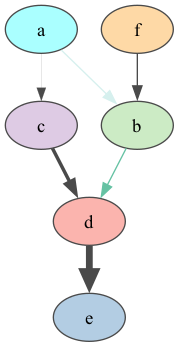

In [13]:
bn = gum.fastBN("a->b->d;a->c->d[3]->e;f->b")
gumimage.export(
  bn,
  "out/export/test_export.png",
  nodeColor={"a": 1, "b": 0.3, "c": 0.4, "d": 0.1, "e": 0.2, "f": 0.5},
  arcColor={(0, 1): 0.2, (1, 2): 0.5},
  arcWidth={(0, 3): 0.4, (3, 2): 0.5, (2, 4): 0.6},
)

Image(filename="out/export/test_export.png")

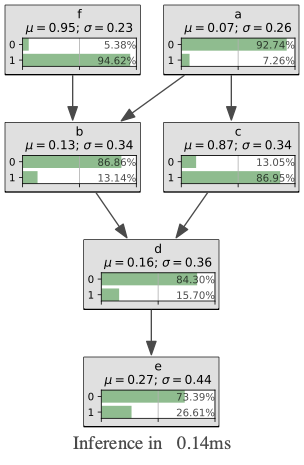

In [14]:
gumimage.exportInference(bn, "out/export/test_export.png")

Image(filename="out/export/test_export.png")

In [15]:
gumimage.export(bn, "out/export/test_export.pdf")

<a href="out/export/test_export.pdf" target="_blank">Link to <tt>out/export/test_export.pdf</tt></a>

### exporting inference with evidence

In [16]:
bn = gum.loadBN("res/alarm.dsl")
gumimage.exportInference(
  bn,
  "out/export/test_export.pdf",
  evs={"CO": 1, "VENTLUNG": 1},
  targets={
    "VENTALV",
    "CATECHOL",
    "HR",
    "MINVOLSET",
    "ANAPHYLAXIS",
    "STROKEVOLUME",
    "ERRLOWOUTPUT",
    "HBR",
    "PULMEMBOLUS",
    "HISTORY",
    "BP",
    "PRESS",
    "CO",
  },
  size="15!",
)

<a href="out/export/test_export.pdf" target="_blank">Link to <tt>out/export/test_export.pdf</tt></a>

### Other models

Other models can also use these functions.

In [17]:
infdiag = gum.loadID("res/OilWildcatter.bifxml")
gumimage.export(infdiag, "out/export/test_export.pdf")

<a href="out/export/test_export.pdf" target="_blank">Link to <tt>out/export/test_export.pdf</tt></a>

In [18]:
gumimage.exportInference(infdiag, "out/export/test_export.pdf")

<a href="out/export/test_export.pdf" target="_blank">Link to <tt>out/export/test_export.pdf</tt></a>

### Exporting any object with `toDot()` method

/var/folders/r1/pj4vdx_n4_d_xpsb04kzf97r0000gp/T/ipykernel_36100/1867421729.py:1: DeprecationWarning: Module 'causal' is deprecated in pyAgrum >2.3.2. Use 'pyagrum.CausalModel' (and so on) instead.
  import pyagrum.causal as csl


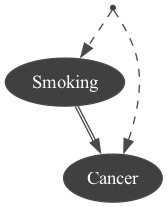

In [19]:
import pyagrum.causal as csl

obs1 = gum.fastBN("Smoking->Cancer")
modele3 = csl.CausalModel(obs1, [("Genotype", ["Smoking", "Cancer"])], True)
gumimage.export(modele3, "out/export/test_export.png")  # a causal model has a toDot method.
Image(filename="out/export/test_export.png")

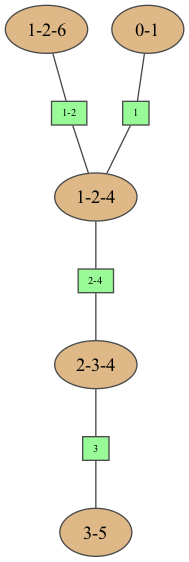

In [20]:
bn = gum.fastBN("a->b->c->d;b->e->d->f;g->c")
ie = gum.LazyPropagation(bn)
jt = ie.junctionTree()
gumimage.export(jt, "out/export/test_export.png")  # a JunctionTree has a method jt.toDot()
Image(filename="out/export/test_export.png")

### ... or even a string in dot syntax

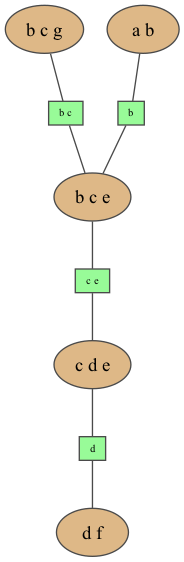

In [21]:
gumimage.export(
  jt.toDotWithNames(bn), "out/export/test_export.png"
)  # jt.toDotWithNames(bn) creates a dot-string for a junction tree with names of variables
Image(filename="out/export/test_export.png")

### Exporting to pyplot

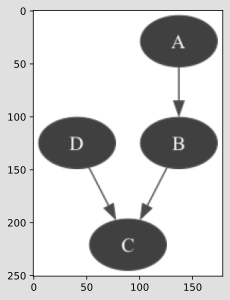

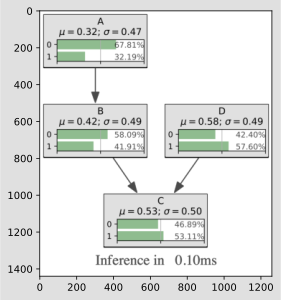

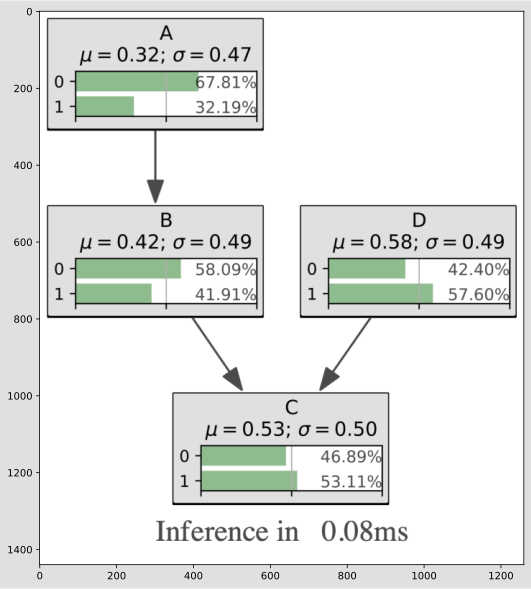

In [22]:
import matplotlib.pyplot as plt

bn = gum.fastBN("A->B->C<-D")

plt.imshow(gumimage.export(bn))
plt.show()

plt.imshow(gumimage.exportInference(bn, size="15!"))
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(gumimage.exportInference(bn, size="15!"))
plt.show()

## Exporting CPTs and HTML views

`pyagrum.lib.image.export()` handles any object with a `_repr_html_()` method
(CPTs, `inspectBN`, sideBySide, explain.Information…) in addition to graphical models.

In [23]:
bn = gum.fastBN("A->B<-C", 3)
gumimage.export(bn.cpt("B"), "out/export/cpt_B_.pdf")

In [24]:
gumimage.export(gnb.getSideBySide(bn, bn.cpt("A"), bn.cpt("B"), bn.cpt("C")), "out/export/sideBySide.pdf")

In [25]:
import pyagrum.explain as gexplain

gumimage.export(gexplain.getInformation(bn), "out/export/informationBN.pdf")

In [26]:
gumimage.export(gnb.inspectBN(bn), "out/export/inspectBN.pdf")

### Adjusting PDF margins

PDF export adds margins around the content (default: 50px horizontal, 37px vertical).
These can be changed via `gum.config` — using `push`/`pop` to restore defaults afterwards.

In [27]:
gum.config.push()
gum.config.asInt["notebook", "export_pdf_margin_x"] = 10
gum.config.asInt["notebook", "export_pdf_margin_y"] = 10
gumimage.export(bn.cpt("B"), "out/export/cpt_B_tight.pdf")
gum.config.pop()

In [28]:
gum.config.push()
gum.config.asInt["notebook", "export_pdf_margin_x"] = 30
gum.config.asInt["notebook", "export_pdf_margin_y"] = 30
gumimage.export(gnb.inspectBN(bn), "out/export/tootight_inspectBN.pdf")
gum.config.pop()